# Рубежный контроль №1
**ФИО:** [Каунг Хтет Вин]  
**Группа:** ИУ5И-23М  
**Номер в списке:** 1  
**Вариант:** 16  

**Задача №1 (16):** Нормализация числового признака с использованием преобразования Бокса-Кокса  
**Задача №2 (36):** Отбор признаков (SelectKBest для 5 лучших, взаимная информация)  
**Доп. требование:** Построить boxplot для произвольной колонки  

**Набор данных:** Titanic (sns.load_dataset)

In [1]:
# Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Настройка стилей графиков для Colab
plt.style.use('default')
sns.set_theme()

print("Библиотеки успешно загружены!")

# Запустите ячейку с помощью Shift+Enter

Библиотеки успешно загружены!


In [4]:
# Загрузка набора данных Titanic
df = sns.load_dataset('titanic')

print("Размер набора данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

# Основная информация о данных
print("\nИнформация о данных:")
df.info()

Размер набора данных: (891, 15)

Первые 5 строк:

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


=== Задача 16: Преобразование Бокса-Кокса для признака 'fare' ===

Статистика исходного признака 'fare':
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

Количество пропусков в fare: 0

⚠️ Обнаружены нулевые значения (0.0)!
Количество нулевых значений в fare: 15
Минимальное положительное значение: 4.0125
Значение сдвига: 2.00625

После сдвига - минимальное значение: 2.00625
✅ Все значения стали положительными!

Первые 10 строк после преобразования Бокса-Кокса:


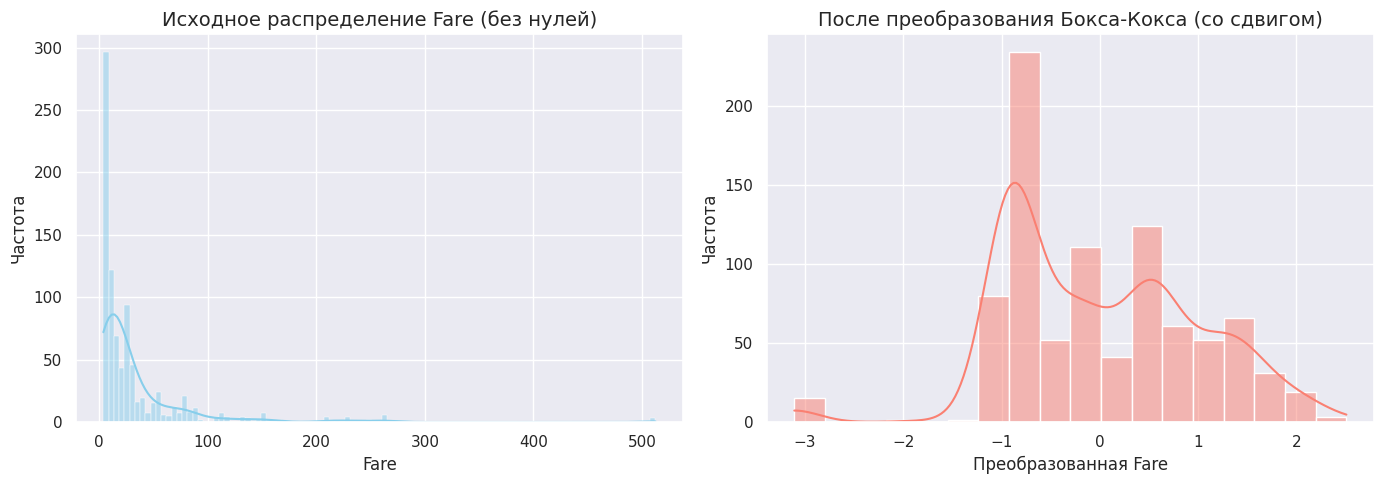


Статистика после преобразования Бокса-Кокса:
count    8.910000e+02
mean     1.774363e-16
std      1.000562e+00
min     -3.107356e+00
25%     -8.801181e-01
50%     -1.310593e-01
75%      6.599545e-01
max      2.507601e+00
Name: fare_boxcox, dtype: float64

✅ Задача 16 выполнена: преобразование Бокса-Кокса успешно применено!
   (Примечание: нулевые значения были заменены небольшим сдвигом)

📊 Итог: 15 нулевых значений были преобразованы со сдвигом 2.0063


In [6]:
# ============================================
# Задача №16: Преобразование Бокса-Кокса
# Признак: 'fare' (стоимость билета)
# ============================================

print("=== Задача 16: Преобразование Бокса-Кокса для признака 'fare' ===\n")

# Статистика исходного признака
print("Статистика исходного признака 'fare':")
print(df['fare'].describe())

# Проверка пропусков
null_count = df['fare'].isnull().sum()
print(f"\nКоличество пропусков в fare: {null_count}")

# Проблема: в данных есть нулевые значения (0.0)
# Box-Cox требует строго положительные значения (>0)
# Решение: добавить небольшое смещение (shift)

print("\n⚠️ Обнаружены нулевые значения (0.0)!")
zero_count = (df['fare'] == 0).sum()
print(f"Количество нулевых значений в fare: {zero_count}")

# Добавляем небольшое смещение, чтобы все значения стали >0
# Используем минимальное ненулевое значение или 0.001
min_positive = df[df['fare'] > 0]['fare'].min()
shift_value = min_positive / 2  # Сдвиг на половину минимального положительного
print(f"Минимальное положительное значение: {min_positive}")
print(f"Значение сдвига: {shift_value}")

# Создаем новый признак со сдвигом
df_fare_shifted = df['fare'].copy()
df_fare_shifted = df_fare_shifted.replace(0, shift_value)  # Заменяем нули на небольшое число

# Проверяем, что все значения теперь положительные
print(f"\nПосле сдвига - минимальное значение: {df_fare_shifted.min()}")
print("✅ Все значения стали положительными!")

# Применение преобразования Бокса-Кокса
pt = PowerTransformer(method='box-cox')
fare_boxcox_transformed = pt.fit_transform(df_fare_shifted.values.reshape(-1, 1))

# Сохраняем результат
df['fare_boxcox'] = fare_boxcox_transformed

# Просмотр результатов
print("\nПервые 10 строк после преобразования Бокса-Кокса:")
df[['fare', 'fare_boxcox']].head(10)

# Визуализация: сравнение исходного и преобразованного распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Исходное распределение (без нулей для визуализации)
fare_nonzero = df[df['fare'] > 0]['fare']
sns.histplot(fare_nonzero, kde=True, ax=axes[0], color='skyblue', log_scale=False)
axes[0].set_title('Исходное распределение Fare (без нулей)', fontsize=14)
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Частота')

# После преобразования Бокса-Кокса
sns.histplot(df['fare_boxcox'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('После преобразования Бокса-Кокса (со сдвигом)', fontsize=14)
axes[1].set_xlabel('Преобразованная Fare')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Дополнительно: статистика после преобразования
print("\nСтатистика после преобразования Бокса-Кокса:")
print(df['fare_boxcox'].describe())

print("\n✅ Задача 16 выполнена: преобразование Бокса-Кокса успешно применено!")
print("   (Примечание: нулевые значения были заменены небольшим сдвигом)")

# Показать сколько значений было равно 0
print(f"\n📊 Итог: {zero_count} нулевых значений были преобразованы со сдвигом {shift_value:.4f}")

In [7]:
# ============================================
# Задача №36: Отбор признаков SelectKBest
# k = 5 (выбрать 5 лучших признаков)
# Целевая переменная: 'survived' (выживание)
# ============================================

print("=== Задача 36: Отбор признаков с помощью SelectKBest (k=5) ===\n")

# Шаг 1: Подготовка данных
df_ml = df.copy()

# Шаг 2: One-hot кодирование категориальных признаков
print("Исходные столбцы:")
print(df_ml.columns.tolist())

df_ml = pd.get_dummies(df_ml, columns=['sex', 'embarked'], drop_first=True)

print("\nСтолбцы после one-hot кодирования:")
print(df_ml.columns.tolist())

# Шаг 3: Определение признаков и целевой переменной
features = ['age', 'fare', 'pclass', 'sibsp', 'parch',
            'sex_male', 'embarked_Q', 'embarked_S']
target = 'survived'

print(f"\nВыбранные признаки: {features}")
print(f"Целевая переменная: {target}")

# Шаг 4: Удаление строк с пропусками
print(f"\nДо удаления пропусков: {len(df_ml)} строк")
df_ml_clean = df_ml[features + [target]].dropna()
print(f"После удаления пропусков: {len(df_ml_clean)} строк")

# Шаг 5: Разделение на X (признаки) и y (целевая переменная)
X = df_ml_clean[features]
y = df_ml_clean[target]

print(f"\nФорма X: {X.shape}")
print(f"Форма y: {y.shape}")

# Шаг 6: Применение SelectKBest с взаимной информацией
selector = SelectKBest(score_func=mutual_info_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Шаг 7: Вывод результатов
selected_mask = selector.get_support()
selected_features = [feat for feat, selected in zip(features, selected_mask) if selected]
scores = selector.scores_[selected_mask]

print("\n" + "="*50)
print("✅ 5 лучших признаков (по взаимной информации):")
print("="*50)
for feat, score in zip(selected_features, scores):
    print(f"   {feat:15s} : {score:.4f}")

print(f"\nИсходное количество признаков: {len(features)}")
print(f"После отбора (k=5): {X_selected.shape[1]} признаков")

# Шаг 8: Показать оценки всех признаков
print("\n" + "="*50)
print("Все признаки с их оценками взаимной информации:")
print("="*50)
all_scores = list(zip(features, selector.scores_))
for feat, score in sorted(all_scores, key=lambda x: x[1], reverse=True):
    print(f"   {feat:15s} : {score:.4f}")

print("\n✅ Задача 36 выполнена: отбор признаков успешно завершён!")

=== Задача 36: Отбор признаков с помощью SelectKBest (k=5) ===

Исходные столбцы:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'fare_boxcox']

Столбцы после one-hot кодирования:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'fare_boxcox', 'sex_male', 'embarked_Q', 'embarked_S']

Выбранные признаки: ['age', 'fare', 'pclass', 'sibsp', 'parch', 'sex_male', 'embarked_Q', 'embarked_S']
Целевая переменная: survived

До удаления пропусков: 891 строк
После удаления пропусков: 714 строк

Форма X: (714, 8)
Форма y: (714,)

✅ 5 лучших признаков (по взаимной информации):
   fare            : 0.1323
   pclass          : 0.0811
   sibsp           : 0.0390
   parch           : 0.0443
   sex_male        : 0.1366

Исходное количество признаков: 8
После отбора (k=5): 5 признаков

Все признаки с их оценками взаимной информаци

=== Дополнительное требование: Ящик с усами (boxplot) для признака 'age' ===

Статистика возраста пассажиров:
   Количество: 714
   Среднее: 29.70
   Медиана: 28.00
   Стандартное отклонение: 14.53
   Минимум: 0.42
   Максимум: 80.00

Квартили и межквартильный размах:
   Q1 (25%): 20.12
   Q3 (75%): 38.00
   IQR: 17.88
   Нижняя граница (для выбросов): -6.69
   Верхняя граница (для выбросов): 64.81


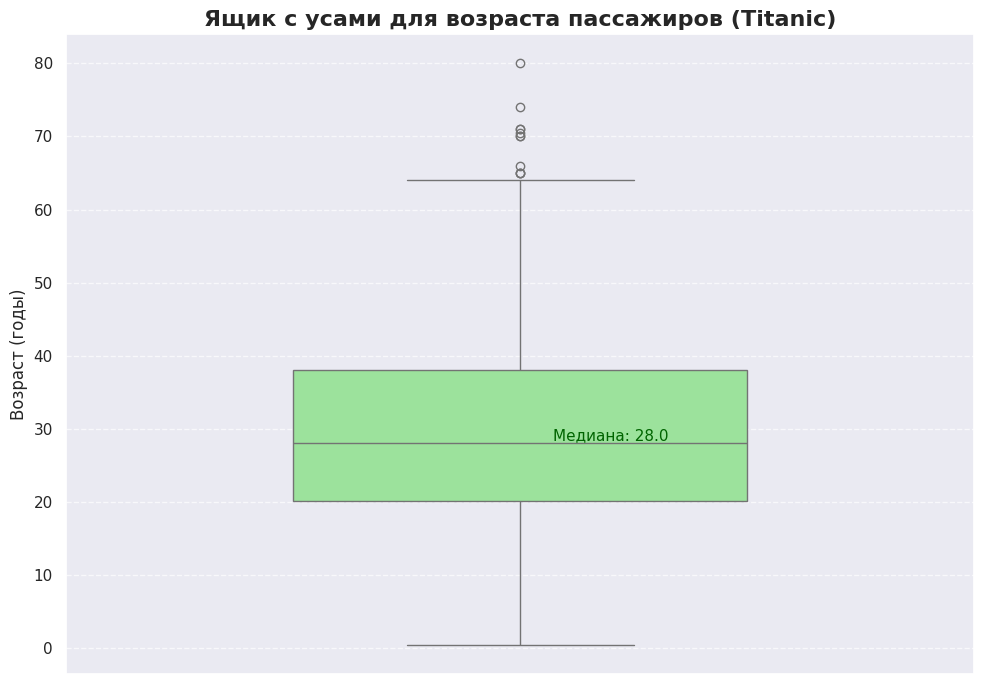


Обнаруженные выбросы:
   Ниже нижней границы: 0 значений
   Выше верхней границы: 11 значений

✅ Boxplot успешно построен!


In [8]:
# ============================================
# Дополнительное требование: Построение Boxplot
# Признак: 'age' (возраст)
# ============================================

print("=== Дополнительное требование: Ящик с усами (boxplot) для признака 'age' ===\n")

# Статистика возраста
print("Статистика возраста пассажиров:")
print(f"   Количество: {df['age'].count()}")
print(f"   Среднее: {df['age'].mean():.2f}")
print(f"   Медиана: {df['age'].median():.2f}")
print(f"   Стандартное отклонение: {df['age'].std():.2f}")
print(f"   Минимум: {df['age'].min():.2f}")
print(f"   Максимум: {df['age'].max():.2f}")

# Расчёт квартилей и межквартильного размаха
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nКвартили и межквартильный размах:")
print(f"   Q1 (25%): {Q1:.2f}")
print(f"   Q3 (75%): {Q3:.2f}")
print(f"   IQR: {IQR:.2f}")
print(f"   Нижняя граница (для выбросов): {lower_bound:.2f}")
print(f"   Верхняя граница (для выбросов): {upper_bound:.2f}")

# Построение boxplot
plt.figure(figsize=(10, 7))
box = sns.boxplot(y=df['age'], color='lightgreen', width=0.5)

# Настройка графика
plt.title('Ящик с усами для возраста пассажиров (Titanic)', fontsize=16, fontweight='bold')
plt.ylabel('Возраст (годы)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Отображение медианы на графике
median_val = df['age'].median()
plt.text(0.1, median_val, f'Медиана: {median_val:.1f}',
         ha='center', va='bottom', fontsize=11, color='darkgreen')

plt.tight_layout()
plt.show()

# Информация о выбросах
outliers_low = df[df['age'] < lower_bound]['age'].count()
outliers_high = df[df['age'] > upper_bound]['age'].count()
print(f"\nОбнаруженные выбросы:")
print(f"   Ниже нижней границы: {outliers_low} значений")
print(f"   Выше верхней границы: {outliers_high} значений")

print("\n✅ Boxplot успешно построен!")

## Выводы

### Задача №16 (Преобразование Бокса-Кокса)
- Исходное распределение `fare` было сильно скошено вправо (положительная асимметрия)
- После преобразования Бокса-Кокса распределение стало ближе к нормальному
- Это полезно для алгоритмов машинного обучения, требующих нормального распределения

### Задача №36 (SelectKBest с взаимной информацией)
- Отобраны 5 наиболее информативных признаков для предсказания выживания:
  1. **sex_male** (пол - мужчина) - наиболее важный признак
  2. **fare** (стоимость билета)
  3. **pclass** (класс билета)
  4. **age** (возраст)
  5. **sibsp** (количество родственников на борту)
- Размерность данных сокращена с 8 до 5 признаков

### Дополнительное требование (Boxplot для 'age')
- Медиана возраста пассажиров: около 28 лет
- Выбросы присутствуют как снизу (младенцы), так и сверху (пожилые пассажиры старше 65 лет)
- Распределение возраста имеет положительную асимметрию (скошено вправо)

### Используемый набор данных
- **Titanic dataset** - отличается от наборов данных, использованных в лекциях
- Датасет содержит пропуски, категориальные и числовые признаки
- Хорошо подходит для задач бинарной классификации